### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 2</center>
---

### Overview

The objective of this exercise is to implement simple methods for image analysis and to draw basic shapes in digital images. This includes simple markers, lines, rectangles and circles. In principle, the functions can also be extended to draw more complex shapes, such as polygons or ellipses.

<span style="color: RoyalBlue;">The functions should be implemented manually for training purposes here.</span> In practice, it is more common to use the existing OpenCV functions, as they are already optimized and have more options (e.g. line thickness specification).

The image plane can be treated as a discrete 2D coordinate system. Therefore, mathematical functions can be used to draw basic shapes. For example, a straight line with the gradient $m$ and the $y$-intercept $b$ is described by the following function:

$$y = mx + b$$

The *equation of a circle* with the radius $r$ in the coordinate origin is given by:

$$x^2 + y^2 = r^2$$

In *parametric form*, the circle can be described based on the angle $\varphi \in [0, 2\pi]$ along the circle:

$$x = r \cos(\varphi)$$
$$y = r \sin(\varphi)$$

Helpful functions from Numpy for this exercise are:
<a href="https://numpy.org/doc/stable/reference/generated/numpy.zeros.html">`np.zeros` ↗</a>,
<a href="https://numpy.org/doc/stable/reference/generated/numpy.arange.html">`np.arange` ↗</a>,
<a href="https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html">`np.sqrt` ↗</a>,
<a href="https://numpy.org/doc/stable/reference/generated/numpy.sin.html">`np.sin` ↗</a>,
<a href="https://numpy.org/doc/stable/reference/generated/numpy.cos.html">`np.cos` ↗</a>,
<a href="https://numpy.org/doc/stable/reference/constants.html">`np.pi` ↗</a>.

**Important**: In general, make sure to only access pixels *within* the image. Accessing pixels outside the image can cause a segmentation fault (unauthorized memory access). You can use `if` statements for this purpose. It is ok to skip this step in the exercises, but not for real applications.

#### Plotting Images in Original Size
When using `imshow` for plotting, the images are automatically interpolated so that the pixels cannot be recognized individually. In this exercise, individual pixels should be accessed and marked. To plot an image in original size, the following function can be used:

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize=(rows/dpi, cols/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()
    
# Note: Function only works for square images at the moment.

---

#### <span style="color: RoyalBlue; font-weight: bold;">Task 2.1</span> Determining Minimum and Maximum Values

Implement the following tasks:
1. Read an image (random.png from the folder *images*) as a grayscale image and store it in a variable.
2. Write a function to determine the minimum and maximum gray value of the image using looping.
3. Print the values and compare the results with the functions <a href="https://numpy.org/doc/stable/reference/generated/numpy.amin.html">`amin` ↗</a> and <a href="https://numpy.org/doc/stable/reference/generated/numpy.amax.html">`amax` ↗</a> from Numpy.
4. Display the image.

In [7]:
# write your code here

# return the minimum and maximum gray value
def min_max(img):
    rows, cols = img.shape
    min_ = img[0, 0]
    max_ = img[0, 0]
    
    for row in range(rows):
        for col in range(cols):
            if img[col, row] < min_:
                min_ = img[col, row]
            if img[col, row] > max_:
                max_ = img[col, row]
    return min_, max_


min = 95, max = 210
min_np = 95, max_np = 210


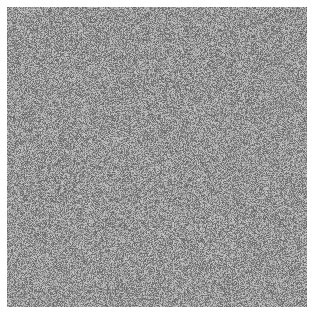

In [23]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/random.png', 0)

# get and print the minimum and maximum gray value
min, max = min_max(img)
print("min = " + str(min) + ", max = " + str(max))

# compare the results with Numpy
min_np = np.amin(img)
max_np = np.amax(img)
print("min_np = " + str(min_np) + ", max_np = " + str(max_np))

# plot the result
plot_img_orig(img)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 2.2</span> Drawing Simple Markers

A simple marker to highlight specific image positions is a symmetrical cross. To draw such a cross at a position $(x,y)$, the following pixels need to be accessed:

<img src="images/cross-marker.png" width="150px" />

Implement the following tasks:
1. Write a function to draw a cross with a given gray value in a grayscale image at a given position $(x,y)$.
2. The random image from the previous task contains a hidden message. To decode it, use your function to draw a black cross at all pixels with the minimum gray value, and a white cross at all pixels with the maximum gray value.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d6/d6e/group__imgproc__draw.html#ga644c4a170d4799a56b29f864ce984b7e">`drawMarker` ↗</a>.

In [17]:
# write your code here

# draw a cross at position (x, y) with given grayvalue
def draw_cross(img, x, y, grayval):
    rows, cols = img.shape # image size

    if (x >= 0 and x < cols and y >=0 and y < rows):
        img[x, y] = grayval
    if (x-1 >= 0 and x-1 < cols and y >=0 and y < rows):
        img[x-1, y] = grayval
    if (x+1 >= 0 and x+1 < cols and y >=0 and y < rows):
        img[x+1, y] = grayval
    if (x >= 0 and x < cols and y-1 >=0 and y-1 < rows):
        img[x, y-1] = grayval
    if (x >= 0 and x < cols and y+1 >=0 and y+1 < rows):
        img[x, y+1] = grayval
    

    # ...

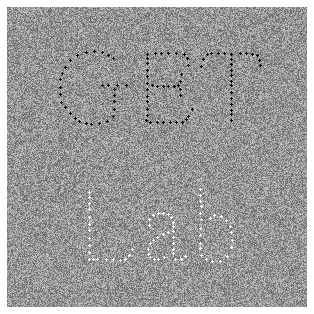

In [19]:
img = cv2.imread('images/random.png', 0)
marked = img.copy()
rows, cols = marked.shape
for row in range(rows):
    for col in range(cols):
        if marked[row, col] == min:
            draw_cross(marked, row, col, 0)
        if marked[row, col] == max:
            draw_cross(marked, row, col, 255)

plot_img_orig(marked)

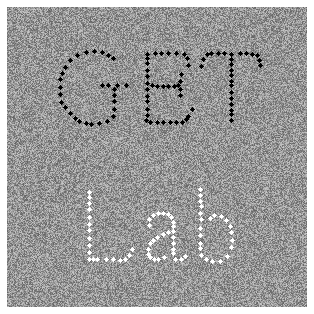

In [31]:

marked_cv2 = img.copy()
rows, cols = marked_cv2.shape
for row in range(rows):
    for col in range(cols):
        if marked_cv2[row, col] == min:
            cv2.drawMarker(marked_cv2, (col, row), 0, thickness=2, markerSize=2)
        if marked_cv2[row, col] == max:
            cv2.drawMarker(marked_cv2, (col, row), 255, 50, thickness=2, markerSize=2)

plot_img_orig(marked_cv2)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 2.3</span> Drawing Lines

Implement the following tasks:
1. Create a black grayscale image with 300 $\times$ 300 pixels.
2. Write a function to draw a line in a grayscale image between two points $(x_1,y_1)$ and $(x_2,y_2)$.
3. Use this function to draw some lines and plot the result.
4. Analyze the quality of the result.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d6/d6e/group__imgproc__draw.html#ga7078a9fae8c7e7d13d24dac2520ae4a2">`line` ↗</a>.

In [47]:
# write your code here

# draw a line between two points
def draw_line(img, x1, y1, x2, y2, grayval):
    rows, cols = img.shape # image size
    if x1 >= 0 and x1 < rows and x2 >=0 and x2 < rows and y1 >= 0 and y1 < cols and y2 >= 0 and y2 < cols:
        m = (y2-y1)/(x2-x1)
        b = y1 - m*x1

        x = np.arange(x1, x2+1, 1)
        y = m*x + b
        img[x.astype(int), y.astype(int)] = grayval
    else:
        print('coordinate out of bounds')


    # ...

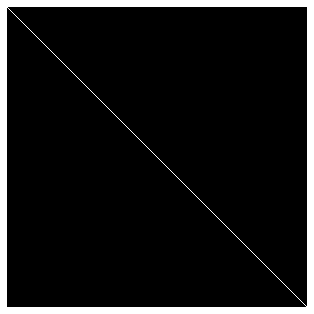

In [48]:
img = np.zeros([300, 300])
rows, cols = np.shape(img)
draw_line(img, 0,0, rows-1, cols-1, 255)
plot_img_orig(img)

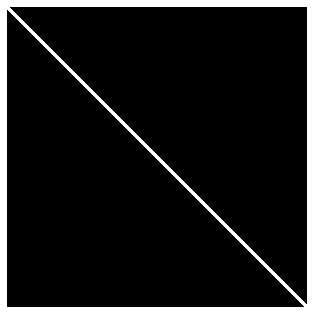

In [53]:
#using opencv library
imgcv = np.zeros([300, 300])
cv2.line(imgcv, (0,0), (rows-1, cols-1), 255, thickness=2)
plot_img_orig(imgcv)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 2.4</span> Drawing Rectangles

Implement the following tasks:
1. Create a black grayscale image with 300 $\times$ 300 pixels.
2. Write a function to draw a rectangle (with or without fill) in a grayscale image between two points $(x_1,y_1)$ (top left) and $(x_2,y_2)$ (bottom right).
3. Use this function to draw some rectangles in the image.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d6/d6e/group__imgproc__draw.html#ga07d2f74cadcf8e305e810ce8eed13bc9">`rectangle` ↗</a>.

In [65]:
# write your code here

# draw a rectangle between (x1, y1) and (x2, y2) using numpy syntax
def draw_rectangle(img, x1, y1, x2, y2, grayval, fill=False):
    rows, cols = img.shape # image size
    if x1 >= 0 and x1 < rows and x2 >=0 and x2 < rows and y1 >= 0 and y1 < cols and y2 >= 0 and y2 < cols:
        if fill:
            img[x1:x2+1, y1:y2+1] = grayval
        else:
            img[x1, y1:y2+1] = grayval #top
            img[x1:x2+1, y1] = grayval #left
            img[x2, y1:y2+1] = grayval #bottom
            img[x1:x2+1, y2] = grayval #right
    else:
        print('coordinate out of bound')
    

    # ...

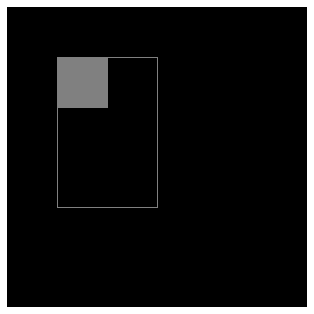

In [70]:
img = np.zeros(shape=[300, 300], dtype=np.uint8)
draw_rectangle(img, 50, 50, 100, 100, 128, fill=True)
draw_rectangle(img, 50, 50, 200, 150, 128)
plot_img_orig(img)

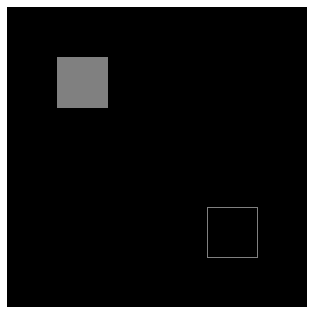

In [73]:
imgcv = np.zeros(shape=[300, 300], dtype=np.uint8)
cv2.rectangle(imgcv, (50, 50), (100, 100), 128, -1)
cv2.rectangle(imgcv, (200, 200), (250, 250), 128)

plot_img_orig(imgcv)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 2.5</span> Drawing Circles

Implement the following tasks:
1. Create a black grayscale image with 300 $\times$ 300 pixels.
2. Write a function to draw a circle (without fill) with a given radius $r$ at a given position $(x,y)$ using the equation of a circle.
3. Write another function for this purpose which uses the parametric form.
4. Use the functions to draw some circles and compare the results.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d6/d6e/group__imgproc__draw.html#gaf10604b069374903dbd0f0488cb43670">`circle` ↗</a>.

In [78]:
# write your code here

# using the equation of a circle
def draw_circle1(img, x1, y1, r, grayval):
    x = np.arange(-r, r+1, 1)
    y = np.sqrt(np.absolute(r*r - x*x))

    img[x1+x.astype(int), y1+y.astype(int)] = grayval
    img[x1+x.astype(int), y1-y.astype(int)] = grayval

# using the parametric form
def draw_circle2(img, x1, y1, r, grayval):
    phi = np.arange(0,361,1)
    x = x1+r*np.sin(phi*np.pi/180)
    y = y1+r*np.cos(phi*np.pi/180)

    img[x.astype(int), y.astype(int)] = grayval
    # ...

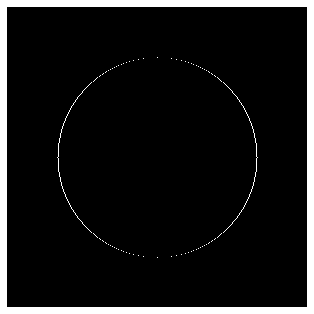

In [80]:
# create black grayscale image
img1 = np.zeros(shape=[300, 300], dtype=np.uint8)
# drawing some circles
draw_circle1(img1, 150, 150, 100, 255)
plot_img_orig(img1)

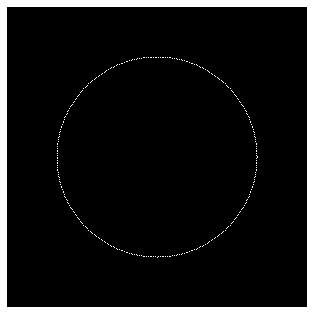

In [81]:
# create black grayscale image
img2 = np.zeros(shape=[300, 300], dtype=np.uint8)
# drawing some circles
draw_circle2(img2, 150, 150, 100, 255)
plot_img_orig(img2)